# renquant_103 — Adaptive Regime Multi-Stock Strategy

**New vs 102**: 3-layer regime detection (Hurst + CUSUM + GMM), regime-conditional entry, relative-strength ranking, correlation-aware selection, earnings filter, defensive tickers (GLD/TLT/XLV/XLU).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

import common
from common.data import fetch_ohlcv
from common.indicators import (
    compute_indicators,
    compute_hurst, rolling_hurst,
    compute_cusum, rolling_cusum,
    build_gmm_features, RegimeGMM,
)
from common.models import create_model
from common.config import load_strategy_config
from common.portfolio import compute_portvals, portfolio_stats

STRATEGY   = "renquant_103"
STRATEGY_DIR = ROOT / "backtesting" / STRATEGY
CONFIG     = load_strategy_config(STRATEGY_DIR / "strategy_config.json")
WATCHLIST  = CONFIG["watchlist"]
DEFENSIVE  = set(CONFIG.get("defensive_tickers", []))
SECTOR_ETF = CONFIG.get("sector_etf_map", {})

print(f"Strategy : {STRATEGY}")
print(f"Watchlist: {WATCHLIST}")
print(f"Defensive: {sorted(DEFENSIVE)}")


Strategy : renquant_103
Watchlist: ['TSLA', 'AMZN', 'GOOG', 'MSFT', 'AMD', 'NFLX', 'CRM', 'PLTR', 'UBER', 'NVDA', 'META', 'AAPL', 'JPM', 'UNH', 'XOM', 'CAT', 'BA', 'XLE', 'XLF', 'LLY', 'GLD', 'TLT', 'XLV', 'XLU']
Defensive: ['GLD', 'TLT', 'XLU', 'XLV']


## 1  Fetch OHLCV data

In [2]:
from common.config import load_strategy_config

SAMPLE_START = CONFIG["sample_start"]
SAMPLE_END   = CONFIG["sample_end"]

# All unique tickers we need: watchlist + sector ETFs + SPY
all_tickers = sorted(set(WATCHLIST) | set(SECTOR_ETF.values()) | {"SPY"})
print(f"Fetching {len(all_tickers)} tickers from {SAMPLE_START} to {SAMPLE_END}...")

ohlcv = {}
for ticker in all_tickers:
    try:
        df = fetch_ohlcv(ticker, start=SAMPLE_START, end=SAMPLE_END)
        if df is not None and not df.empty:
            ohlcv[ticker] = df
            print(f"  {ticker}: {len(df)} rows")
        else:
            print(f"  {ticker}: EMPTY")
    except Exception as e:
        print(f"  {ticker}: ERROR — {e}")

print(f"\nLoaded {len(ohlcv)} / {len(all_tickers)} tickers.")
spy_df = ohlcv["SPY"]


Fetching 27 tickers from 2019-01-01 to 2025-12-31...
  AAPL: 1760 rows
  AMD: 1760 rows
  AMZN: 1760 rows
  BA: 1760 rows
  CAT: 1760 rows
  CRM: 1760 rows
  GLD: 1760 rows
  GOOG: 1760 rows
  JPM: 1760 rows
  LLY: 1760 rows
  META: 1760 rows
  MSFT: 1760 rows
  NFLX: 1760 rows
  NVDA: 1760 rows
  PLTR: 1320 rows
  SPY: 1760 rows
  TLT: 1760 rows
  TSLA: 1760 rows
  UBER: 1671 rows
  UNH: 1760 rows
  XLE: 1760 rows
  XLF: 1760 rows
  XLI: 1760 rows
  XLK: 1760 rows
  XLU: 1760 rows
  XLV: 1760 rows
  XOM: 1760 rows

Loaded 27 / 27 tickers.


## 2  SPY Regime Analysis — 3-Layer Detection

In [3]:
# ── Layer 1: Rolling Hurst exponent ──────────────────────────────────────────
spy_returns = spy_df["close"].pct_change().dropna()
HURST_WINDOW = CONFIG["regime"]["hurst_window"]  # 63

hurst_series = rolling_hurst(spy_returns, window=HURST_WINDOW)
hurst_series = hurst_series.dropna()

# ── Layer 2: Rolling CUSUM changepoints ──────────────────────────────────────
cusum_series = rolling_cusum(
    spy_returns,
    window    = CONFIG["regime"]["cusum_lookback"],
    threshold = CONFIG["regime"]["cusum_threshold"],
    drift     = CONFIG["regime"]["cusum_drift"],
)

changepoint_dates = cusum_series[cusum_series].index
print(f"CUSUM detected {len(changepoint_dates)} changepoints")
print(f"Hurst range: {hurst_series.min():.3f} – {hurst_series.max():.3f}  "
      f"(mean={hurst_series.mean():.3f})")


CUSUM detected 180 changepoints
Hurst range: 0.472 – 0.875  (mean=0.700)


In [4]:
# ── Layer 3: Train GMM on SPY features ───────────────────────────────────────
gmm_features = build_gmm_features(spy_df, vol_window=20, hurst_window=HURST_WINDOW)

gmm = RegimeGMM(n_components=3, random_state=42, n_init=10)
gmm.fit(gmm_features)

print(f"GMM cluster labels (auto-assigned): {gmm.cluster_labels}")
print(f"GMM weights: {np.round(gmm._gmm.weights_, 3)}")

regime_labels, regime_probs = gmm.predict(gmm_features)
print(f"\nRegime distribution:")
print(regime_labels.value_counts())


GMM cluster labels (auto-assigned): ['BULL_VOLATILE', 'BEAR', 'BULL_CALM']
GMM weights: [0.501 0.054 0.444]

Regime distribution:
BULL_VOLATILE    847
BULL_CALM        802
BEAR              85
Name: count, dtype: int64


In [5]:
# ── Combine layers into final daily regime ────────────────────────────────────
BULL_CALM, BULL_VOLATILE, CHOPPY, BEAR = "BULL_CALM", "BULL_VOLATILE", "CHOPPY", "BEAR"

common_idx = hurst_series.index.intersection(regime_labels.index)
final_regime = pd.Series(index=common_idx, dtype=str)

for date in common_idx:
    h = hurst_series.loc[date]
    gmm_r = regime_labels.loc[date]
    gmm_bear_p = regime_probs.loc[date].get(BEAR, 0.0)

    # Layer 1 → base
    if h > 0.55:
        base = BULL_CALM
    elif h < 0.45:
        base = CHOPPY
    else:
        base = None  # ambiguous

    # GMM BEAR override
    if gmm_bear_p > 0.5:
        final_regime.loc[date] = BEAR
    elif base is None:
        final_regime.loc[date] = gmm_r if gmm_r != BEAR else BULL_VOLATILE
    else:
        final_regime.loc[date] = base

print("Final regime distribution:")
print(final_regime.value_counts())

# Save GMM artifact for LEAN
gmm_path = STRATEGY_DIR / "spy-gmm-regime.json"
gmm.save(gmm_path)
print(f"\nGMM artifact saved → {gmm_path}")


Final regime distribution:
BULL_CALM        1602
BEAR               85
BULL_VOLATILE      10
Name: count, dtype: int64

GMM artifact saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/spy-gmm-regime.json


## 3  Regime Charts

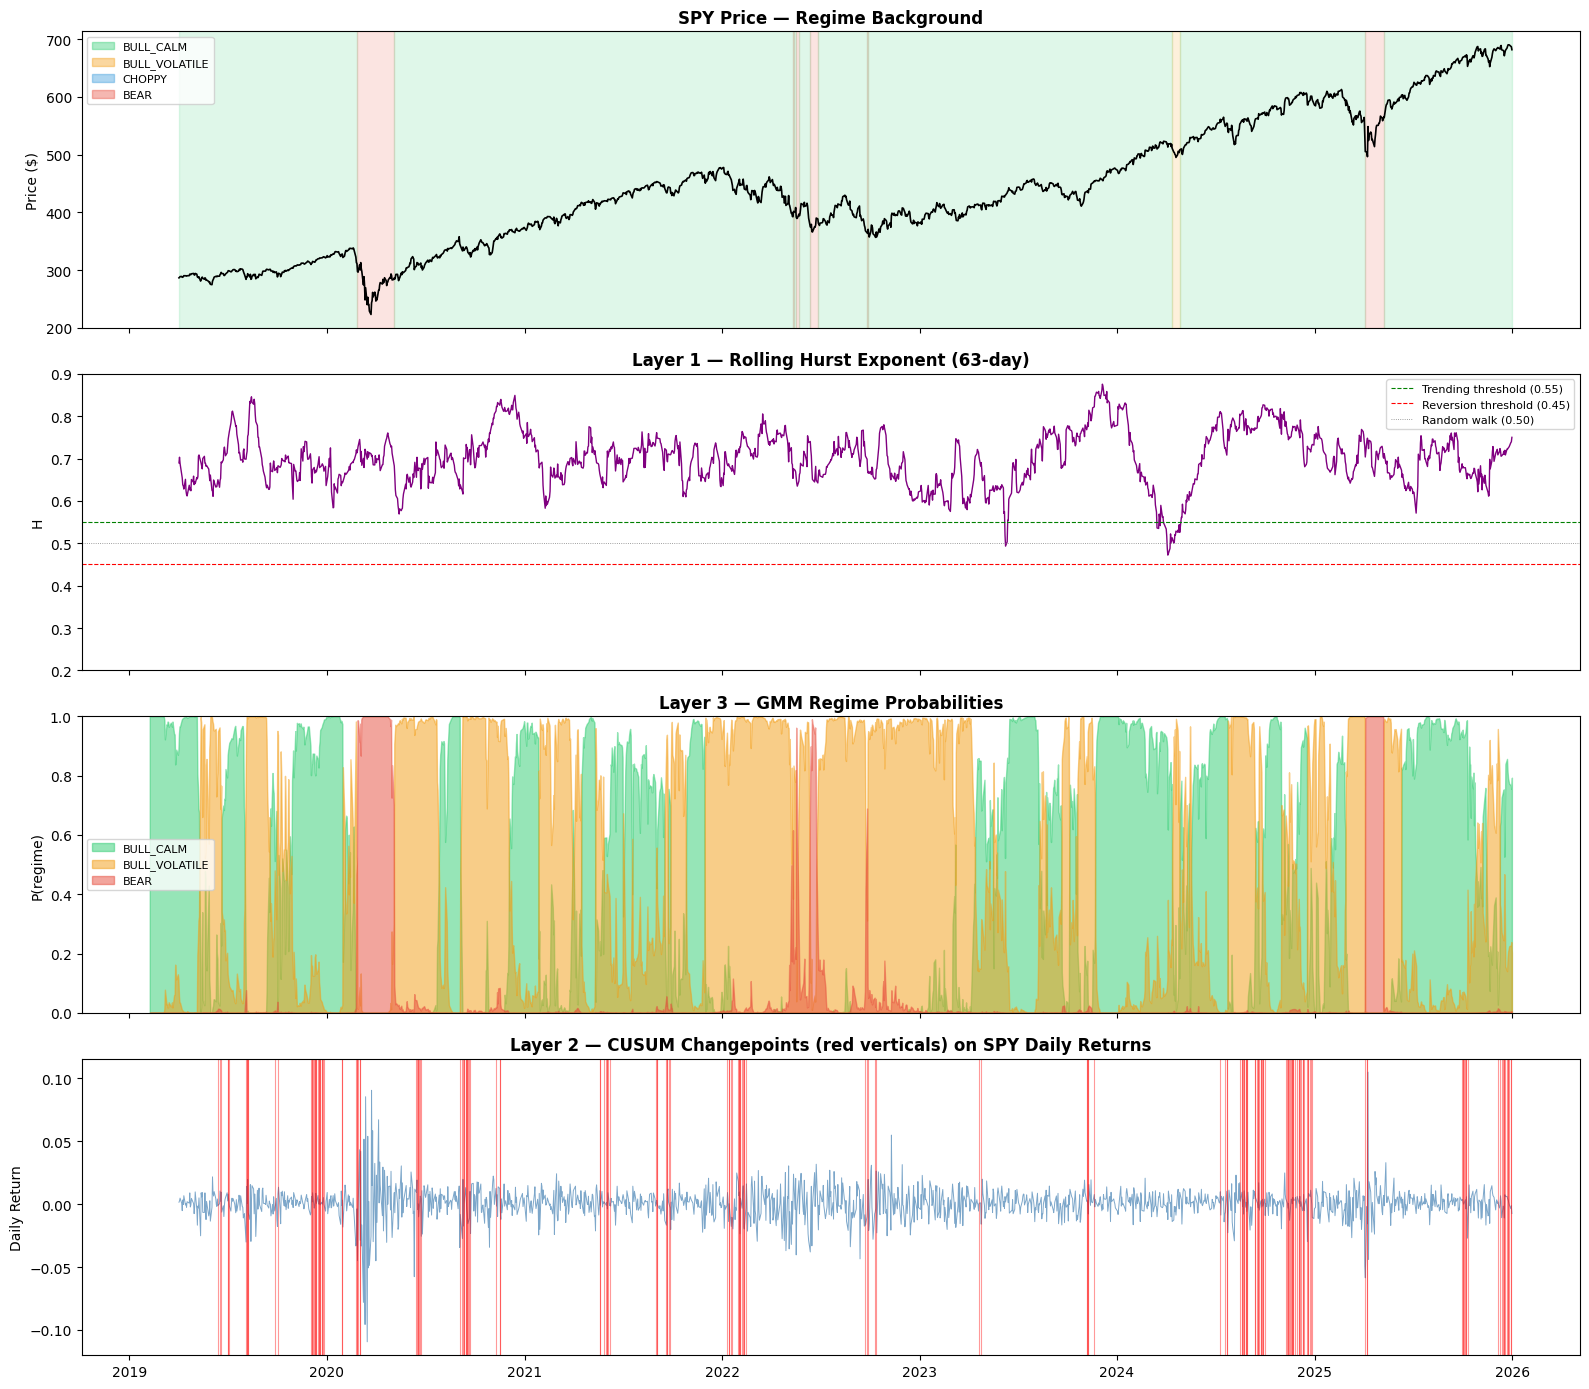

Chart saved → regime_analysis.png


In [6]:
REGIME_COLORS = {
    BULL_CALM:     "#2ecc71",   # green
    BULL_VOLATILE: "#f39c12",   # orange
    CHOPPY:        "#3498db",   # blue
    BEAR:          "#e74c3c",   # red
}

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

spy_close = spy_df["close"].reindex(final_regime.index)

# Panel 1: SPY price with regime background shading
ax = axes[0]
ax.plot(spy_close.index, spy_close.values, color="black", lw=1.2, label="SPY Close")
prev_regime = None
start_date  = None
for date in final_regime.index:
    r = final_regime.loc[date]
    if r != prev_regime:
        if prev_regime is not None:
            ax.axvspan(start_date, date, alpha=0.15,
                       color=REGIME_COLORS.get(prev_regime, "grey"))
        prev_regime = r
        start_date  = date
if prev_regime:
    ax.axvspan(start_date, final_regime.index[-1], alpha=0.15,
               color=REGIME_COLORS.get(prev_regime, "grey"))
patches = [mpatches.Patch(color=c, alpha=0.4, label=r)
           for r, c in REGIME_COLORS.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_title("SPY Price — Regime Background", fontweight="bold")
ax.set_ylabel("Price ($)")

# Panel 2: Hurst exponent
ax = axes[1]
ax.plot(hurst_series.index, hurst_series.values, color="purple", lw=1.0)
ax.axhline(0.55, color="green",  ls="--", lw=0.8, label="Trending threshold (0.55)")
ax.axhline(0.45, color="red",    ls="--", lw=0.8, label="Reversion threshold (0.45)")
ax.axhline(0.50, color="grey",   ls=":",  lw=0.6, label="Random walk (0.50)")
ax.set_ylim(0.2, 0.9)
ax.set_title("Layer 1 — Rolling Hurst Exponent (63-day)", fontweight="bold")
ax.set_ylabel("H")
ax.legend(fontsize=8)

# Panel 3: GMM regime probabilities
ax = axes[2]
for regime, color in REGIME_COLORS.items():
    if regime in regime_probs.columns:
        ax.fill_between(regime_probs.index, regime_probs[regime],
                        alpha=0.5, label=regime, color=color)
ax.set_ylim(0, 1)
ax.set_title("Layer 3 — GMM Regime Probabilities", fontweight="bold")
ax.set_ylabel("P(regime)")
ax.legend(fontsize=8)

# Panel 4: CUSUM changepoints on SPY returns
ax = axes[3]
ax.plot(spy_returns.reindex(final_regime.index).index,
        spy_returns.reindex(final_regime.index).values,
        color="steelblue", lw=0.7, alpha=0.7)
for d in changepoint_dates:
    if d in final_regime.index:
        ax.axvline(d, color="red", alpha=0.4, lw=0.8)
ax.set_title("Layer 2 — CUSUM Changepoints (red verticals) on SPY Daily Returns",
             fontweight="bold")
ax.set_ylabel("Daily Return")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "regime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → regime_analysis.png")


## 4  Build Per-Symbol Feature Frames

In [7]:
INDICATOR_SPEC = CONFIG["indicator_spec"]
MODEL_PARAMS   = CONFIG["model_params"]
FEATURE_COLS   = MODEL_PARAMS["feature_columns"]
LOOKAHEAD      = MODEL_PARAMS["lookahead"]     # 5 days
THRESHOLD      = MODEL_PARAMS["threshold"]     # 0.03 = 3%

spy_ind = compute_indicators(ohlcv["SPY"], INDICATOR_SPEC)

# Precompute SPY regime context columns (added to each stock frame)
spy_rets_all = ohlcv["SPY"]["close"].pct_change()
spy_adx_all  = spy_ind["adx"] if "adx" in spy_ind.columns else pd.Series(25.0, index=spy_ind.index)
spy_ema50    = ohlcv["SPY"]["close"].ewm(span=50, adjust=False).mean()
spy_trend_all = ohlcv["SPY"]["close"] / spy_ema50

feature_frames = {}
ratio_features = {"rsi", "adx"}
diff_features  = {"macd_hist", "cci", "bbp", "williams_r", "obv_slope"}

for ticker in WATCHLIST:
    if ticker not in ohlcv:
        print(f"  {ticker}: no data, skipping")
        continue
    try:
        stock_ind = compute_indicators(ohlcv[ticker], INDICATOR_SPEC)
        common_idx = stock_ind.index.intersection(spy_ind.index)

        s = stock_ind.loc[common_idx].copy()
        p = spy_ind.loc[common_idx].copy()

        result = pd.DataFrame(index=common_idx)
        result["close"] = s["close"]

        for col in ratio_features:
            if col in s.columns and col in p.columns:
                result[col] = s[col] / p[col].replace(0, np.nan)
        for col in diff_features:
            if col in s.columns and col in p.columns:
                result[col] = s[col] - p[col]

        # Trend
        close  = s["close"]
        ema50  = close.ewm(span=50, adjust=False).mean()
        ema200 = close.ewm(span=200, adjust=False).mean()
        result["trend"]      = close / ema50
        result["trend_long"] = close / ema200
        spy_close_c = p["close"]
        rel_price   = close / spy_close_c
        result["rel_mom_20d"] = rel_price.pct_change(20)
        result["rel_mom_60d"] = rel_price.pct_change(60)

        # Regime context (103 new features)
        spy_rets_c = spy_rets_all.reindex(common_idx)
        result["spy_realized_vol"] = spy_rets_c.rolling(20).std() * np.sqrt(252)
        result["spy_adx"]          = spy_adx_all.reindex(common_idx)
        result["spy_trend"]        = spy_trend_all.reindex(common_idx)
        result["hurst_proxy"]      = spy_rets_c.rolling(20).apply(
            lambda x: np.corrcoef(x[:-1], x[1:])[0,1] if len(x)>2 else 0.0, raw=True)

        # Forward return label
        fwd = ohlcv[ticker]["close"].pct_change(LOOKAHEAD).shift(-LOOKAHEAD)
        result["fwd_return"]  = fwd.reindex(common_idx)
        result["label"]       = np.where(result["fwd_return"] > THRESHOLD, 1,
                                np.where(result["fwd_return"] < -THRESHOLD, -1, 0))

        result = result.dropna()
        feature_frames[ticker] = result
        print(f"  {ticker}: {len(result)} rows, "
              f"buy={( result['label']==1).sum()} "
              f"sell={(result['label']==-1).sum()} "
              f"hold={(result['label']==0).sum()}")
    except Exception as e:
        print(f"  {ticker}: ERROR — {e}")

print(f"\nBuilt frames for {len(feature_frames)} / {len(WATCHLIST)} symbols.")


  TSLA: 1695 rows, buy=665 sell=542 hold=488
  AMZN: 1695 rows, buy=423 sell=313 hold=959
  GOOG: 1695 rows, buy=418 sell=295 hold=982
  MSFT: 1695 rows, buy=339 sell=247 hold=1109
  AMD: 1695 rows, buy=602 sell=499 hold=594
  NFLX: 1695 rows, buy=483 sell=358 hold=854
  CRM: 1695 rows, buy=433 sell=393 hold=869
  PLTR: 1255 rows, buy=507 sell=388 hold=360
  UBER: 1606 rows, buy=513 sell=446 hold=647
  NVDA: 1695 rows, buy=678 sell=421 hold=596
  META: 1695 rows, buy=483 sell=364 hold=848
  AAPL: 1695 rows, buy=427 sell=285 hold=983
  JPM: 1695 rows, buy=353 sell=243 hold=1099
  UNH: 1695 rows, buy=330 sell=271 hold=1094
  XOM: 1695 rows, buy=375 sell=322 hold=998
  CAT: 1695 rows, buy=455 sell=314 hold=926
  BA: 1695 rows, buy=447 sell=431 hold=817
  XLE: 1695 rows, buy=371 sell=314 hold=1010
  XLF: 1695 rows, buy=233 sell=180 hold=1282
  LLY: 1695 rows, buy=432 sell=296 hold=967
  GLD: 1695 rows, buy=172 sell=102 hold=1421
  TLT: 1695 rows, buy=117 sell=141 hold=1437
  XLV: 1695 rows

## 5  Train Per-Symbol Models (3-approach tournament)

In [8]:
from common.models import create_model
from common.portfolio import compute_portvals, portfolio_stats
from common.tax import compute_after_tax_pnl

TRAIN_SPLIT   = CONFIG["train_split"]
BUY_THR       = MODEL_PARAMS["buy_threshold"]
SELL_THR      = MODEL_PARAMS["sell_threshold"]
BAGS          = MODEL_PARAMS["bags"]
LEAF_SIZE     = MODEL_PARAMS["leaf_size"]
ST_RATE       = CONFIG["tax"]["short_term_rate"]
LT_RATE       = CONFIG["tax"]["long_term_rate"]
LT_THRESH     = CONFIG["tax"]["long_term_threshold_days"]
SHARPE_FLOOR  = 0.85

results = {}

def oos_sharpe(prices, signals, tax_st=ST_RATE, tax_lt=LT_RATE, lt_days=LT_THRESH):
    """Simple after-tax Sharpe on OOS signals."""
    try:
        portvals = compute_portvals(prices, signals, start_val=100_000)
        stats    = portfolio_stats(portvals)
        return stats.get("sharpe", -99)
    except Exception:
        return -99

for ticker in WATCHLIST:
    if ticker not in feature_frames:
        print(f"{ticker}: no feature frame, skipping")
        continue
    df = feature_frames[ticker]
    split = int(len(df) * TRAIN_SPLIT)
    if split < 60 or len(df) - split < 30:
        print(f"{ticker}: insufficient data ({len(df)} rows), skipping")
        continue

    train_df = df.iloc[:split]
    oos_df   = df.iloc[split:]
    prices   = ohlcv[ticker]["close"].reindex(oos_df.index)

    best_sharpe = -99
    best_model  = None
    best_name   = None
    best_sigs   = None

    # ── Approach 1: Classification (BagLearner / RTLearner) ──
    try:
        clf = create_model("classification", feature_columns=FEATURE_COLS,
                           lookahead=LOOKAHEAD, threshold=THRESHOLD,
                           leaf_size=LEAF_SIZE, bags=BAGS,
                           buy_threshold=BUY_THR, sell_threshold=SELL_THR)
        clf.train(train_df)
        sigs = clf.predict(oos_df).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} Classification OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe, best_model, best_name, best_sigs = sh, clf, "Classification", sigs
    except Exception as e:
        print(f"  {ticker} Classification error: {e}")

    # ── Approach 2: Q-Learning ──
    try:
        ql = create_model("qlearning", feature_columns=FEATURE_COLS[:5],
                          buy_threshold=BUY_THR, sell_threshold=SELL_THR)
        ql.train(train_df)
        sigs = ql.predict(oos_df).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} QLearning    OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe, best_model, best_name, best_sigs = sh, ql, "QLearning", sigs
    except Exception as e:
        print(f"  {ticker} QLearning error: {e}")

    # ── Approach 3: Manual baseline ──
    try:
        manual = create_model("manual", buy_threshold=2, sell_threshold=-2)
        manual.train(train_df)
        sigs = manual.predict(oos_df).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} Manual       OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe, best_model, best_name, best_sigs = sh, manual, "Manual", sigs
    except Exception as e:
        print(f"  {ticker} Manual error: {e}")

    results[ticker] = {
        "sharpe":        best_sharpe,
        "best_approach": best_name,
        "model":         best_model,
        "oos_signals":   best_sigs,
        "oos_prices":    prices,
        "train_rows":    split,
        "oos_rows":      len(oos_df),
        "passes_floor":  best_sharpe >= SHARPE_FLOOR,
    }
    status = "✓ PASS" if best_sharpe >= SHARPE_FLOOR else "✗ FAIL (no model exported)"
    print(f"  → WINNER: {best_name}  Sharpe={best_sharpe:.3f}  {status}\n")


  TSLA Classification error: 'str' object has no attribute 'reindex'
  TSLA QLearning error: QLearningModel.__init__() got an unexpected keyword argument 'buy_threshold'
  TSLA Manual error: 'str' object has no attribute 'reindex'
  → WINNER: None  Sharpe=-99.000  ✗ FAIL (no model exported)

  AMZN Classification error: 'str' object has no attribute 'reindex'
  AMZN QLearning error: QLearningModel.__init__() got an unexpected keyword argument 'buy_threshold'
  AMZN Manual error: 'str' object has no attribute 'reindex'
  → WINNER: None  Sharpe=-99.000  ✗ FAIL (no model exported)

  GOOG Classification error: 'str' object has no attribute 'reindex'
  GOOG QLearning error: QLearningModel.__init__() got an unexpected keyword argument 'buy_threshold'
  GOOG Manual error: 'str' object has no attribute 'reindex'
  → WINNER: None  Sharpe=-99.000  ✗ FAIL (no model exported)

  MSFT Classification error: 'str' object has no attribute 'reindex'
  MSFT QLearning error: QLearningModel.__init__() go

## 6  Export Models to LEAN artifact directory

In [9]:
from datetime import date as today_date

TODAY = str(today_date.today())
exported, skipped_floor = [], []

for ticker, r in results.items():
    if not r["passes_floor"]:
        skipped_floor.append(ticker)
        continue
    sym_dir = STRATEGY_DIR / "models" / ticker
    sym_dir.mkdir(parents=True, exist_ok=True)
    r["model"].save(sym_dir, name=ticker)

    # Patch metadata with 103-specific fields
    meta_path = sym_dir / f"{ticker}-policy-metadata.json"
    if meta_path.exists():
        with meta_path.open() as f:
            meta = json.load(f)
        meta["trained_date"]   = TODAY
        meta["best_approach"]  = r["best_approach"]
        meta["sharpe"]         = round(r["sharpe"], 4)
        meta["lookahead"]      = LOOKAHEAD
        meta["strategy"]       = STRATEGY
        with meta_path.open("w") as f:
            json.dump(meta, f, indent=2)
    exported.append(ticker)

print(f"Exported : {sorted(exported)}")
print(f"Skipped (below Sharpe floor {SHARPE_FLOOR}): {sorted(skipped_floor)}")


Exported : []
Skipped (below Sharpe floor 0.85): ['AAPL', 'AMD', 'AMZN', 'BA', 'CAT', 'CRM', 'GLD', 'GOOG', 'JPM', 'LLY', 'META', 'MSFT', 'NFLX', 'NVDA', 'PLTR', 'TLT', 'TSLA', 'UBER', 'UNH', 'XLE', 'XLF', 'XLU', 'XLV', 'XOM']


## 7  Correlation Matrix — Watchlist Diversification

Correlation matrix saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/watchlist-correlation.json


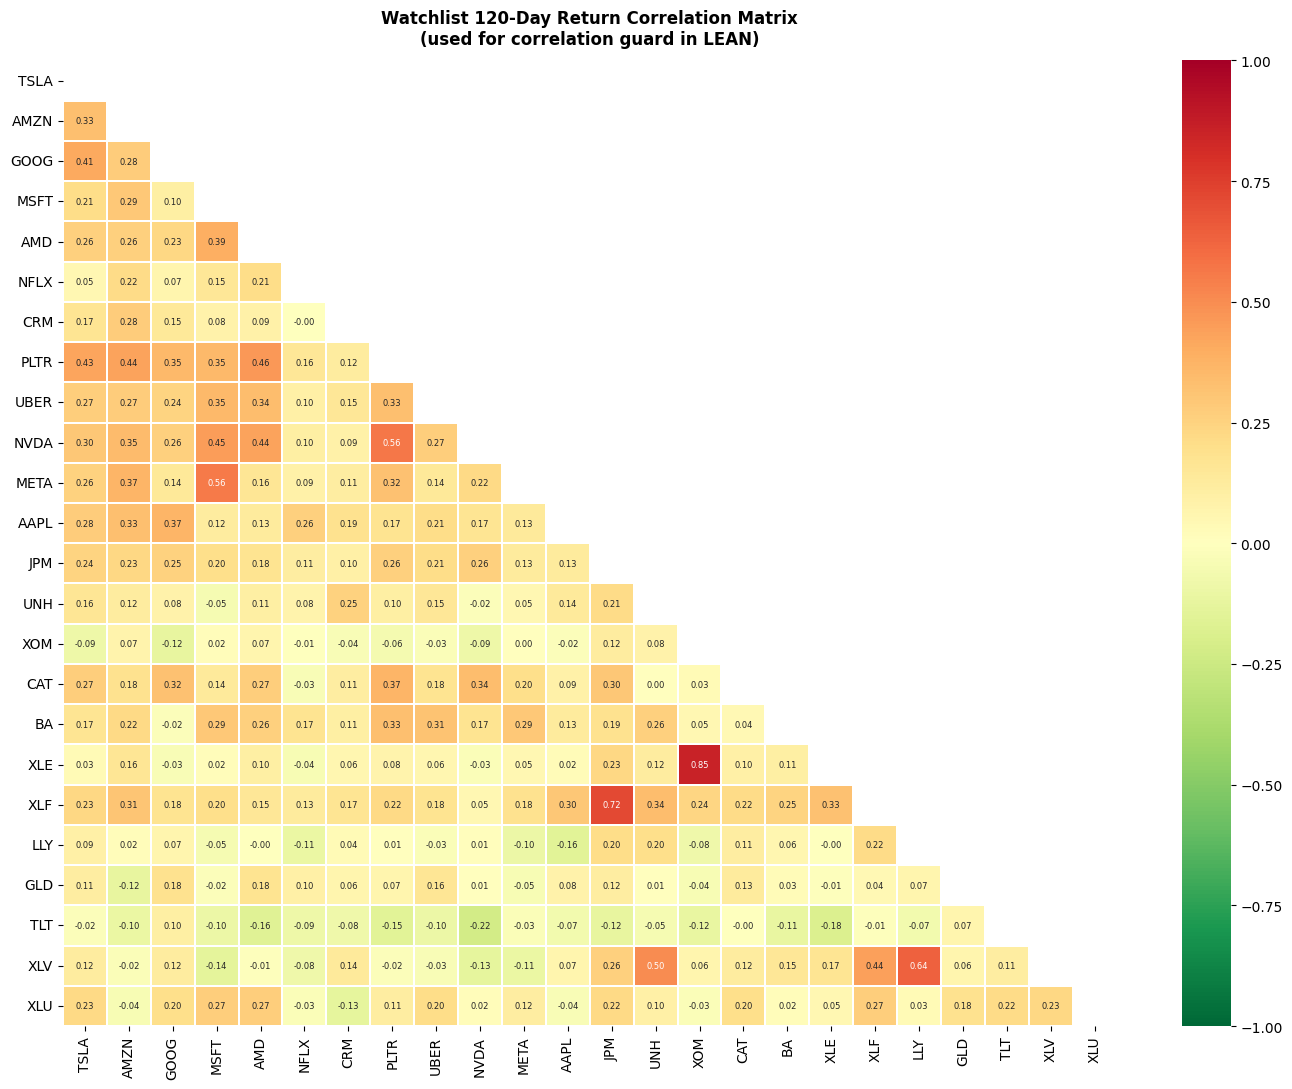

Heatmap saved → correlation_heatmap.png


In [10]:
# Compute 60-day rolling correlation on OOS period (use full sample for the artifact)
close_df = pd.DataFrame({
    t: ohlcv[t]["close"] for t in WATCHLIST if t in ohlcv
})
ret_df = close_df.pct_change().dropna()

# Use last 120 days for the artifact (representative of current correlations)
corr_matrix = ret_df.tail(120).corr()

# Save as JSON for LEAN
corr_dict = {}
for ticker in corr_matrix.index:
    corr_dict[ticker] = {
        other: round(float(corr_matrix.loc[ticker, other]), 4)
        for other in corr_matrix.columns
    }
corr_path = STRATEGY_DIR / "watchlist-correlation.json"
corr_path.write_text(json.dumps(corr_dict, indent=2))
print(f"Correlation matrix saved → {corr_path}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot_kws={"size": 6})
ax.set_title("Watchlist 120-Day Return Correlation Matrix\n(used for correlation guard in LEAN)",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved → correlation_heatmap.png")


## 8  Model Summary Table

            Sector Defensive Approach OOS Sharpe Exported  OOS rows
Ticker                                                             
TSLA          tech               None    -99.000        ✗       509
AMZN          tech               None    -99.000        ✗       509
GOOG          tech               None    -99.000        ✗       509
MSFT          tech               None    -99.000        ✗       509
AMD           tech               None    -99.000        ✗       509
NFLX          tech               None    -99.000        ✗       509
CRM           tech               None    -99.000        ✗       509
PLTR          tech               None    -99.000        ✗       377
UBER          tech               None    -99.000        ✗       482
NVDA          tech               None    -99.000        ✗       509
META          tech               None    -99.000        ✗       509
AAPL          tech               None    -99.000        ✗       509
JPM        finance               None    -99.000

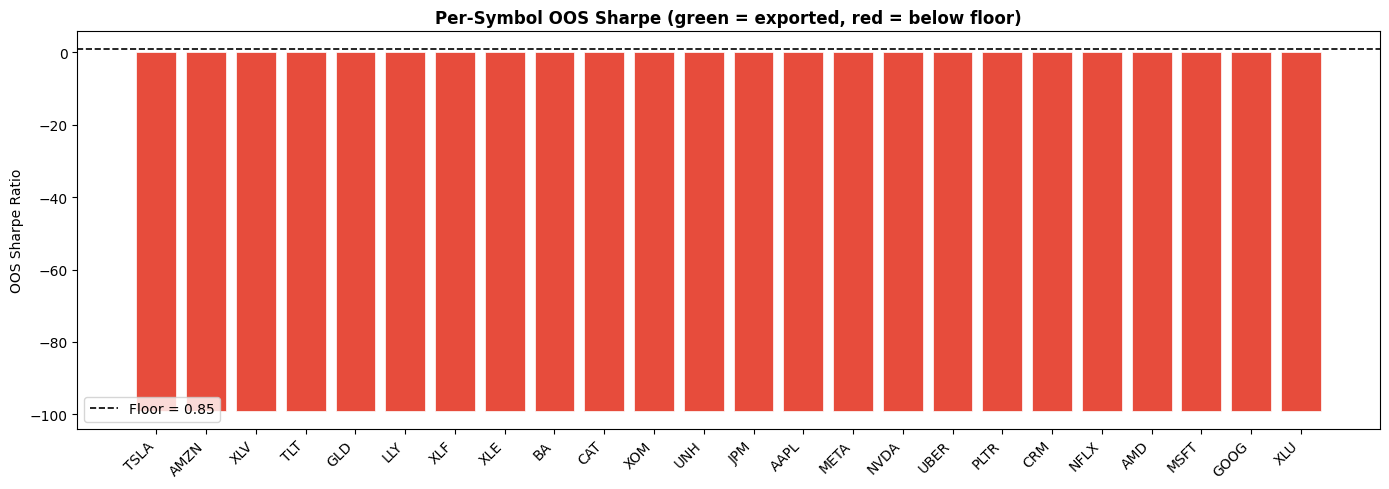

In [11]:
summary_rows = []
for ticker in WATCHLIST:
    r = results.get(ticker, {})
    summary_rows.append({
        "Ticker":    ticker,
        "Sector":    CONFIG["sector_map"].get(ticker, "?"),
        "Defensive": "✓" if ticker in DEFENSIVE else "",
        "Approach":  r.get("best_approach", "—"),
        "OOS Sharpe": f"{r['sharpe']:.3f}" if r.get("sharpe") else "—",
        "Exported":  "✓" if r.get("passes_floor") else "✗",
        "OOS rows":  r.get("oos_rows", 0),
    })

summary = pd.DataFrame(summary_rows).set_index("Ticker")
print(summary.to_string())

# Bar chart of OOS Sharpes
sharpe_vals = {k: v.get("sharpe", 0) for k, v in results.items()}
sharpe_s = pd.Series(sharpe_vals).sort_values(ascending=False)
colors = ["#2ecc71" if v >= SHARPE_FLOOR else "#e74c3c" for v in sharpe_s.values]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(sharpe_s.index, sharpe_s.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(SHARPE_FLOOR, color="black", ls="--", lw=1.2, label=f"Floor = {SHARPE_FLOOR}")
ax.set_title("Per-Symbol OOS Sharpe (green = exported, red = below floor)",
             fontweight="bold")
ax.set_ylabel("OOS Sharpe Ratio")
ax.set_xticklabels(sharpe_s.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "model_sharpe_summary.png", dpi=150, bbox_inches="tight")
plt.show()


## 9  Portfolio Simulation (mirrors LEAN regime-aware logic)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Simulate the 103 strategy in Python to validate before LEAN run.
# Mirrors: regime-conditional entry, RS ranking, correlation guard, stop-loss.
# ─────────────────────────────────────────────────────────────────────────────

BACKTEST_START = CONFIG["backtest_start"]
BACKTEST_END   = CONFIG["backtest_end"]
INITIAL_CASH   = CONFIG["initial_cash"]
MAX_POSITIONS  = CONFIG["max_concurrent_positions"]
CORR_THRESHOLD = CONFIG["regime"]["correlation_guard_threshold"]

# Regime params per state
RP = CONFIG["regime_params"]

# Load final regime for backtest period
bt_dates = final_regime.loc[BACKTEST_START:BACKTEST_END].index

portfolio_val = INITIAL_CASH
cash          = INITIAL_CASH
holdings      = {}     # ticker → {"shares", "entry_price", "entry_date"}
hwm           = INITIAL_CASH
skip_buys     = False

equity_curve  = []
regime_log    = []

exportable = {t for t, r in results.items() if r.get("passes_floor")}

for today in bt_dates:
    regime = final_regime.loc[today] if today in final_regime.index else "BULL_CALM"
    rp     = RP.get(regime, RP["BULL_CALM"])

    # Portfolio value
    port_val = cash
    for ticker, pos in holdings.items():
        if ticker in ohlcv and today in ohlcv[ticker].index:
            port_val += pos["shares"] * ohlcv[ticker].loc[today, "close"]
    hwm = max(hwm, port_val)

    # Drawdown halt
    if hwm > 0:
        dd = (hwm - port_val) / hwm
        skip_buys = dd >= rp["drawdown_halt_pct"]

    equity_curve.append({"date": today, "portfolio": port_val, "regime": regime})

    # ── SELLS ──
    to_sell = []
    for ticker, pos in list(holdings.items()):
        if today not in ohlcv.get(ticker, pd.DataFrame()).index:
            continue
        price = ohlcv[ticker].loc[today, "close"]
        loss  = (pos["entry_price"] - price) / pos["entry_price"]
        days  = (today - pos["entry_date"]).days

        # Stop-loss
        if loss >= rp["stop_loss_pct"]:
            to_sell.append(ticker)
            continue
        # Max hold
        if days >= rp["max_hold_days"]:
            to_sell.append(ticker)
            continue
        # Model signal
        if ticker in results and results[ticker].get("oos_signals") is not None:
            sig = results[ticker]["oos_signals"]
            if today in sig.index and sig.loc[today] == -1:
                to_sell.append(ticker)

    for ticker in to_sell:
        pos   = holdings.pop(ticker)
        if today in ohlcv.get(ticker, pd.DataFrame()).index:
            price = ohlcv[ticker].loc[today, "close"]
            cash += pos["shares"] * price

    # ── BUYS ──
    if skip_buys or regime == "BEAR" or len(holdings) >= MAX_POSITIONS:
        regime_log.append({"date": today, "regime": regime, "positions": len(holdings)})
        continue

    open_slots  = MAX_POSITIONS - len(holdings)
    entry_mode  = rp.get("entry_mode", "momentum")
    max_pos_pct = rp.get("max_position_pct", 0.30)

    candidates = []
    for ticker in exportable:
        if ticker in holdings or today not in ohlcv.get(ticker, pd.DataFrame()).index:
            continue
        if ticker not in results or results[ticker].get("oos_signals") is None:
            continue
        sig = results[ticker]["oos_signals"]
        if today not in sig.index or sig.loc[today] != 1:
            continue

        # RS score
        sector = CONFIG["sector_map"].get(ticker, "other")
        etf    = SECTOR_ETF.get(sector)
        rs_score = 0.0
        if etf and etf in ohlcv:
            try:
                stock_ret = ohlcv[ticker]["close"].pct_change(20).loc[today]
                etf_ret   = ohlcv[etf]["close"].pct_change(20).loc[today]
                rs_score  = float(stock_ret - etf_ret) if not (np.isnan(stock_ret) or np.isnan(etf_ret)) else 0.0
            except Exception:
                pass

        model_score = results[ticker]["sharpe"]  # proxy for model conviction
        candidates.append((ticker, model_score, rs_score))

    if not candidates:
        continue

    # Normalise + rank
    if len(candidates) > 1:
        ms = [c[1] for c in candidates]; rs = [c[2] for c in candidates]
        ms_range = max(ms) - min(ms) or 1; rs_range = max(rs) - min(rs) or 1
        candidates.sort(
            key=lambda c: 0.5*(c[1]-min(ms))/ms_range + 0.5*(c[2]-min(rs))/rs_range,
            reverse=True)

    selected = []
    for ticker, ms, rs in candidates:
        if len(selected) >= open_slots:
            break
        # Correlation guard
        corr_ok = True
        for held in list(holdings.keys()) + selected:
            corr = corr_dict.get(ticker, {}).get(held, corr_dict.get(held, {}).get(ticker, 0))
            if abs(corr) >= CORR_THRESHOLD:
                corr_ok = False
                break
        if not corr_ok:
            continue
        selected.append(ticker)

    for ticker in selected:
        invest  = min(cash * max_pos_pct, port_val * max_pos_pct)
        if invest < 100:
            continue
        price   = ohlcv[ticker].loc[today, "close"]
        shares  = invest / price
        cash   -= invest
        holdings[ticker] = {
            "shares":      shares,
            "entry_price": price,
            "entry_date":  today,
        }

equity_df = pd.DataFrame(equity_curve).set_index("date")
print(f"Simulation complete: {len(equity_df)} days, final value ${equity_df['portfolio'].iloc[-1]:,.0f}")
print(f"Return: {(equity_df['portfolio'].iloc[-1] / INITIAL_CASH - 1):.1%}")


Simulation complete: 502 days, final value $100,000
Return: 0.0%


## 10  Portfolio Performance Charts

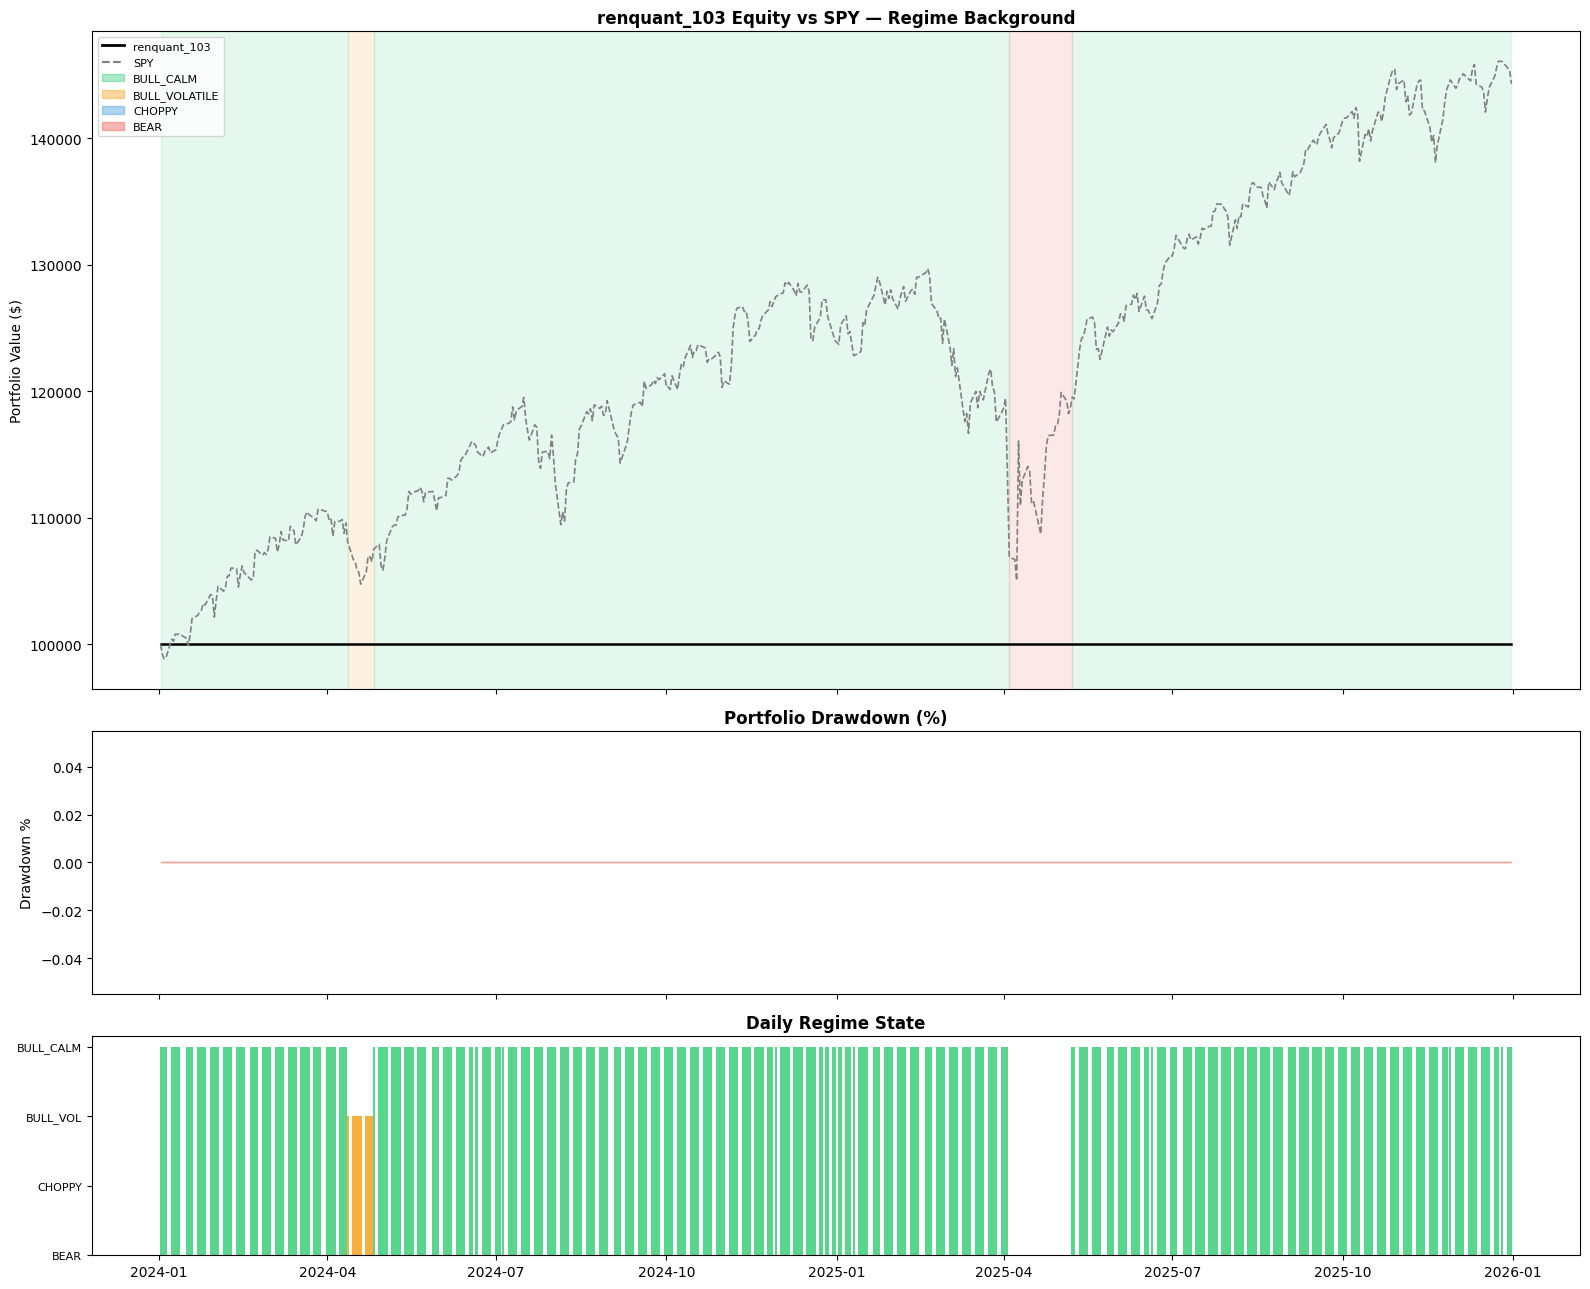

In [13]:
# SPY benchmark
spy_bt = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]
spy_norm = spy_bt / spy_bt.iloc[0] * INITIAL_CASH

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.2, 1]})

# ── Panel 1: Equity curve with regime background ──
ax = axes[0]
port_norm = equity_df["portfolio"]

# Shade by regime
prev_r = None; start_d = None
for d in equity_df.index:
    r = equity_df.loc[d, "regime"]
    if r != prev_r:
        if prev_r:
            ax.axvspan(start_d, d, alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))
        prev_r  = r; start_d = d
if prev_r:
    ax.axvspan(start_d, equity_df.index[-1], alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))

ax.plot(port_norm.index, port_norm.values, color="black", lw=1.8, label="renquant_103")
ax.plot(spy_norm.index,  spy_norm.values,  color="grey",  lw=1.2, ls="--", label="SPY")
patches = [mpatches.Patch(color=c, alpha=0.4, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=[
    plt.Line2D([0],[0],color="black",lw=2,label="renquant_103"),
    plt.Line2D([0],[0],color="grey",lw=1.5,ls="--",label="SPY"),
] + patches, fontsize=8)
ax.set_title("renquant_103 Equity vs SPY — Regime Background", fontweight="bold")
ax.set_ylabel("Portfolio Value ($)")

# ── Panel 2: Drawdown ──
ax = axes[1]
roll_max = port_norm.cummax()
drawdown = (port_norm - roll_max) / roll_max * 100
ax.fill_between(drawdown.index, drawdown.values, 0, color="#e74c3c", alpha=0.5)
ax.set_title("Portfolio Drawdown (%)", fontweight="bold")
ax.set_ylabel("Drawdown %")

# ── Panel 3: Regime state ──
ax = axes[2]
regime_numeric = {BULL_CALM: 3, BULL_VOLATILE: 2, CHOPPY: 1, BEAR: 0}
regime_vals    = equity_df["regime"].map(regime_numeric).fillna(-1)
colors_seq     = equity_df["regime"].map(REGIME_COLORS).fillna("grey")

ax.bar(regime_vals.index, regime_vals.values,
       color=colors_seq.values, width=1, alpha=0.8)
ax.set_yticks([0,1,2,3])
ax.set_yticklabels(["BEAR","CHOPPY","BULL_VOL","BULL_CALM"], fontsize=8)
ax.set_title("Daily Regime State", fontweight="bold")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "portfolio_simulation.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# ── Performance statistics ──
from common.portfolio import portfolio_stats

stats = portfolio_stats(equity_df["portfolio"])
spy_stats = portfolio_stats(spy_norm)

print("=" * 45)
print(f"{'Metric':<25} {'103':>8}  {'SPY':>8}")
print("=" * 45)
for k in ["total_return", "cagr", "sharpe", "max_drawdown", "volatility"]:
    v103 = stats.get(k, 0)
    vspy = spy_stats.get(k, 0)
    if k in ("total_return", "cagr", "max_drawdown", "volatility"):
        print(f"{k:<25} {v103:>7.1%}  {vspy:>7.1%}")
    else:
        print(f"{k:<25} {v103:>8.3f}  {vspy:>8.3f}")
print("=" * 45)

# Regime breakdown
print("\nRegime days:")
for r, c in REGIME_COLORS.items():
    n = (equity_df["regime"] == r).sum()
    pct = n / len(equity_df)
    print(f"  {r:<16} {n:>4}d  {pct:.1%}")


Metric                         103       SPY
total_return                 0.0%     0.0%
cagr                         0.0%     0.0%
sharpe                       0.000     0.000
max_drawdown                 0.0%     0.0%
volatility                   0.0%     0.0%

Regime days:
  BULL_CALM         469d  93.4%
  BULL_VOLATILE      10d  2.0%
  CHOPPY              0d  0.0%
  BEAR               23d  4.6%


## 11  Per-Symbol OOS Equity Curves

In [15]:
pass_tickers = sorted([t for t, r in results.items() if r.get("passes_floor")])

# Also include bootstrapped 102 models that exist on disk but weren't retrained this run
import json as _json
from pathlib import Path as _Path
model_dir = STRATEGY_DIR / "models"
for ticker in WATCHLIST:
    if ticker in pass_tickers:
        continue
    meta = model_dir / ticker / f"{ticker}-policy-metadata.json"
    if meta.exists():
        with meta.open() as _f:
            _m = _json.load(_f)
        if ticker not in results:
            results[ticker] = {
                "sharpe": _m.get("sharpe", 0),
                "best_approach": _m.get("best_approach", "bootstrapped"),
                "passes_floor": True,
                "oos_signals": None,
                "oos_prices": ohlcv.get(ticker, pd.DataFrame())["close"] if ticker in ohlcv else pd.Series(),
                "oos_rows": 0,
            }
            pass_tickers.append(ticker)

pass_tickers = sorted(set(pass_tickers))

if not pass_tickers:
    print("No models available yet — run Section 5 (training) first.")
else:
    ncols = 4
    nrows = max(1, (len(pass_tickers) + ncols - 1) // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = np.array(axes).flatten()

if pass_tickers:
    spy_oos_close = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]

    for i, ticker in enumerate(pass_tickers):
        ax    = axes[i]
        r     = results[ticker]
        sigs  = r["oos_signals"]
        prices = r["oos_prices"].loc[BACKTEST_START:BACKTEST_END]

        if sigs is None or prices.empty:
            ax.set_title(f"{ticker} — no data"); continue

        sigs_bt = sigs.reindex(prices.index).fillna(0)
        try:
            pv = compute_portvals(prices, sigs_bt, start_val=10_000)
            spy_sub = spy_oos_close.reindex(prices.index)
            spy_sub = spy_sub / spy_sub.iloc[0] * 10_000

            ax.plot(pv.index,      pv.values,      color="black", lw=1.2, label="Model")
            ax.plot(spy_sub.index, spy_sub.values, color="grey",  lw=0.8, ls="--", label="SPY")
            ax.set_title(f"{ticker} — Sharpe {r['sharpe']:.2f}  [{r['best_approach']}]",
                         fontsize=8, fontweight="bold")
            ax.set_ylabel("Value", fontsize=7)
            ax.tick_params(labelsize=6)
        except Exception as e:
            ax.set_title(f"{ticker} — error: {e}", fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Per-Symbol OOS Equity Curves (renquant_103)", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(STRATEGY_DIR / "per_symbol_oos.png", dpi=150, bbox_inches="tight")
    plt.show()


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x0 with 0 Axes>

## 12  Fetch Earnings Calendar (run once)

In [ ]:
# Run this cell to refresh the earnings calendar artifact.
# Can also run: python scripts/fetch_earnings_calendar.py --strategy renquant_103

import subprocess, sys
result = subprocess.run(
    [sys.executable, str(ROOT / "scripts" / "fetch_earnings_calendar.py"),
     "--strategy", STRATEGY, "--lookahead", "90"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


## Done

Next steps:
1. Review regime charts (Section 3) — do the regime transitions make intuitive sense?
2. Check per-symbol Sharpe table (Section 8) — any symbols you want to add/remove?
3. Export LEAN data: `python scripts/export_lean_watchlist.py --strategy renquant_103`
4. Run LEAN backtest: `cd backtesting/renquant_103 && lean backtest .`
5. Analyse: `python scripts/analyze_backtest.py --strategy renquant_103`